In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0,'../g3algo/')
import foftools as fof

In [2]:
mock = pd.read_csv("../halobiasgroupcats/fiducial/ECO_cat_0_Planck_memb_cat.csv")

In [3]:
hammass = []
dynmass = []
grpn=[]
truemass=[]
for ii in range(0,8):
    mock = pd.read_csv("../halobiasgroupcats/fiducial/ECO_cat_{}_Planck_memb_cat.csv".format(ii))
    mock.loc[:,'dynmass']=fof.dynmass(mock.ra.to_numpy(),mock.dec.to_numpy(),mock.cz.to_numpy(),mock.g3grp_l.to_numpy(),9.9,0.7)
    mock = mock.groupby('g3grp_l').first()
    hammass.append(mock.g3logmh_l.to_numpy() - np.log10(0.7))
    dynmass.append(mock.dynmass.to_numpy())
    grpn.append(mock.g3grpn_l.to_numpy())
    truemass.append(mock.loghalom.to_numpy())
hammass=np.concatenate(hammass)
dynmass=np.concatenate(dynmass)
grpn=np.concatenate(grpn)
truemass=np.concatenate(truemass)

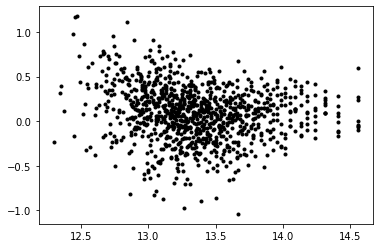

In [4]:
plt.figure()
sel=(grpn>7)
plt.plot(hammass[sel],dynmass[sel]-hammass[sel],'k.')
#plt.xlim(10,15)
#plt.ylim(-3,1)
plt.show()

-0.6195980400142576
-0.38998542239416434


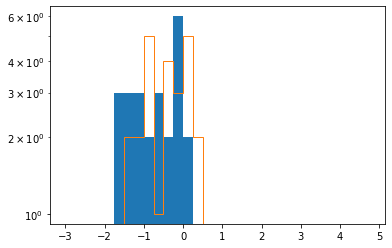

In [5]:
plt.figure()
sel=(grpn>7)&(truemass>14)
binv=np.arange(-3,5,0.25)
plt.hist(hammass[sel]-truemass[sel],bins=binv)
plt.hist(dynmass[sel]-truemass[sel],bins=binv,histtype='step')
print(np.median((hammass[sel]-truemass[sel])))
print(np.median((dynmass[sel]-truemass[sel])))
plt.yscale('log')
plt.show()

0.6195980400142576
0.4005871228045237


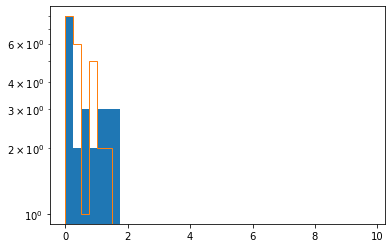

In [6]:
plt.figure()
sel=(grpn>7)&(truemass>14)
binv=np.arange(0,10,0.25)
plt.hist(np.abs(hammass[sel]-truemass[sel]),bins=binv)
plt.hist(np.abs(dynmass[sel]-truemass[sel]),bins=binv,histtype='step')
print(np.median(np.abs(hammass[sel]-truemass[sel])))
print(np.median(np.abs(dynmass[sel]-truemass[sel])))
plt.yscale('log')
plt.show()

In [7]:
eco = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")

In [8]:
eco = eco[(eco.absrmag<-17.33)&(eco.g3fc_l>0)]

In [12]:
grpn = (eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
print(np.sum(np.logical_and(grpn<8,grpn>0))/(np.sum(grpn>0)))

0.9889422539930749


In [14]:
(1-0.98894)*len(eco)

99.02017999999963

In [18]:
results = pd.read_csv("../optimization/table_group_params.csv")

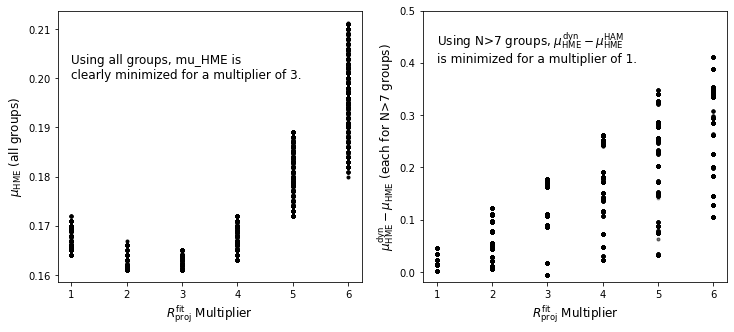

In [19]:
fig,axs=plt.subplots(ncols=2,figsize=(12,5))
axs[0].plot(results.rproj_fit_mult, results.mu_HME,'k.')
axs[1].plot(results.rproj_fit_mult, results.mu_HME_dyn-results.mu_HME_HAMngt7,'k.',alpha=0.3)
axs[0].set_ylabel(r'$\mu_{\rm HME}$ (all groups)',fontsize=12)
axs[1].set_ylabel(r'$\mu_{\rm HME}^{\rm dyn} - \mu_{\rm HME}^{}$ (each for N>7 groups)',fontsize=12)
axs[0].annotate('Using all groups, mu_HME is\nclearly minimized for a multiplier of 3.',xy=(1,0.2),fontsize=12)
axs[1].annotate(r'Using N>7 groups, $\mu_{\rm HME}^{\rm dyn} - \mu_{\rm HME}^{\rm HAM}$'+'\nis minimized for a multiplier of 1.',xy=(1,0.4),fontsize=12)
axs[1].set_ylim(-0.02,0.5)
for ii in range(0,2):
    axs[ii].set_xlabel(r"$R_{\rm proj}^{\rm fit}$ Multiplier",fontsize=12)
plt.show()

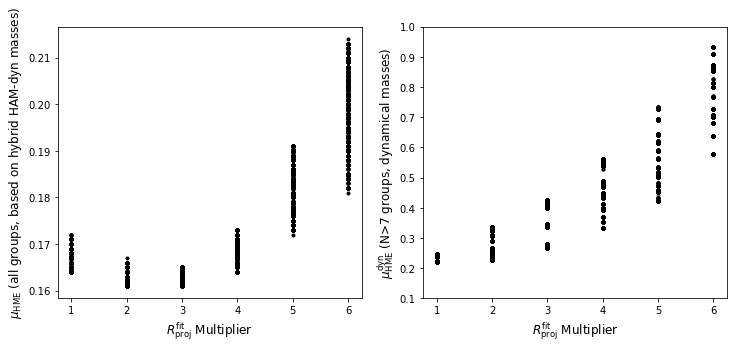

In [22]:
fig,axs=plt.subplots(ncols=2,figsize=(12,5))
axs[0].plot(results.rproj_fit_mult, results.muHME_hybrid,'k.')
axs[1].plot(results.rproj_fit_mult, results.mu_HME_dyn,'k.',alpha=0.3)
axs[0].set_ylabel(r'$\mu_{\rm HME}$ (all groups, based on hybrid HAM-dyn masses)',fontsize=12)
axs[1].set_ylabel(r'$\mu_{\rm HME}^{\rm dyn}$ (N>7 groups, dynamical masses)',fontsize=12)
#axs[0].annotate('Using all groups, mu_HME is\nclearly minimized for a multiplier of 3.',xy=(1,0.2),fontsize=12)
#axs[1].annotate(r'Using N>7 groups, $\mu_{\rm HME}^{\rm dyn} - \mu_{\rm HME}^{\rm HAM}$'+'\nis minimized for a multiplier of 1.',xy=(1,0.4),fontsize=12)
axs[1].set_ylim(0.1,1)
for ii in range(0,2):
    axs[ii].set_xlabel(r"$R_{\rm proj}^{\rm fit}$ Multiplier",fontsize=12)
plt.show()

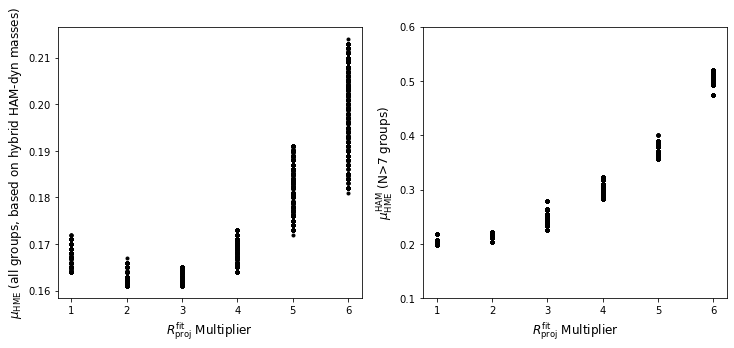

In [21]:
fig,axs=plt.subplots(ncols=2,figsize=(12,5))
axs[0].plot(results.rproj_fit_mult, results.muHME_hybrid,'k.')
axs[1].plot(results.rproj_fit_mult, results.mu_HME_HAMngt7,'k.',alpha=0.3)
axs[0].set_ylabel(r'$\mu_{\rm HME}$ (all groups, based on hybrid HAM-dyn masses)',fontsize=12)
axs[1].set_ylabel(r'$\mu_{\rm HME}^{\rm HAM}$ (N>7 groups)',fontsize=12)
#axs[0].annotate('Using all groups, mu_HME is\nclearly minimized for a multiplier of 3.',xy=(1,0.2),fontsize=12)
#axs[1].annotate(r'Using N>7 groups, $\mu_{\rm HME}^{\rm dyn} - \mu_{\rm HME}^{\rm HAM}$'+'\nis minimized for a multiplier of 1.',xy=(1,0.4),fontsize=12)
axs[1].set_ylim(0.1,0.6)
for ii in range(0,2):
    axs[ii].set_xlabel(r"$R_{\rm proj}^{\rm fit}$ Multiplier",fontsize=12)
plt.show()

In [24]:
results.mu_HME_dyn.min()

0.2204167791946574